# Analisis fase 2: TUI + PGF vs SOTA

Notebook rapido para generar tablas y graficos clave a partir de `results/master_results.csv`.

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuracion de rutas
BASE_DIR = Path.cwd()
MASTER_PATH = BASE_DIR / "master_results.csv"
REPORTS_DIR = BASE_DIR / "plots"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Estetica
sns.set_context("talk")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv(MASTER_PATH)
df.head()

,agent,seed,episodes,risk_scale,kappa,lambda,mix,pgf_neto,tripwires,robustez,flexibilidad,reward_total,filename
0,control,123.0,NaN,0.5,NaN,NaN,NaN,-0.076135,0.0,NaN,NaN,-5.0,sweep_default_seed123_risk0.5_control.csv
1,control,123.0,NaN,0.5,NaN,NaN,NaN,0.000000,0.0,NaN,NaN,0.0,sweep_default_seed123_risk0.5_control.csv
2,control,123.0,NaN,0.5,NaN,NaN,NaN,0.000000,0.0,NaN,NaN,0.0,sweep_default_seed123_risk0.5_control.csv
3,control,123.0,NaN,0.5,NaN,NaN,NaN,0.000000,0.0,NaN,NaN,0.0,sweep_default_seed123_risk0.5_control.csv
4,control,123.0,NaN,0.5,NaN,NaN,NaN,-0.152270,0.0,NaN,NaN,-10.0,sweep_default_seed123_risk0.5_control.csv


In [2]:
# Tabla resumen por agente y riesgo
metrics = ["pgf_neto", "tripwires", "robustez", "flexibilidad", "reward_total"]

grouped = df.groupby(["agent", "risk_scale"])[metrics].agg(["mean", "std", "count"])
summary = grouped.reset_index()
summary.head()

# Guardar
summary_path = REPORTS_DIR / "summary_agent_risk.csv"
summary.to_csv(summary_path, index=False)
summary_path

WindowsPath('C:/Proyectos/TUI-v4.1/results/exp_tui_pgf_vs_sota_2025/plots/summary_agent_risk.csv')

In [3]:
# Mejor agente por riesgo (PGF_neto max y tripwires min)
# Recomputamos medias simples (sin MultiIndex)
agg = df.groupby(["risk_scale", "agent"])[["pgf_neto", "tripwires"]].mean().reset_index()
pgf_idx = agg.groupby("risk_scale")["pgf_neto"].idxmax()
trip_idx = agg.groupby("risk_scale")["tripwires"].idxmin()
best_pgf = agg.loc[pgf_idx, ["risk_scale", "agent", "pgf_neto"]]
best_pgf.columns = ["risk_scale", "best_pgf_agent", "best_pgf_mean"]
best_trip = agg.loc[trip_idx, ["risk_scale", "agent", "tripwires"]]
best_trip.columns = ["risk_scale", "best_trip_agent", "best_trip_mean"]
best_table = best_pgf.merge(best_trip, on="risk_scale")
best_table_path = REPORTS_DIR / "best_agents_by_risk.csv"
best_table.to_csv(best_table_path, index=False)
best_table


,risk_scale,best_pgf_agent,best_pgf_mean,best_trip_agent,best_trip_mean
0,0.5,control,-0.112309,control,0.03
1,1.0,ppo,-0.053623,ppo,0.00
2,1.5,ppo,-0.041784,ppo,0.00
3,2.0,ppo,-0.040391,ppo,0.00
4,3.0,ppo,-0.039695,ppo,0.00


C:\Users\jrivera\AppData\Local\Temp\ipykernel_36108\3444330304.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df, x="risk_scale", y="pgf_neto", hue="agent", estimator="mean", ci="sd")


WindowsPath('C:/Proyectos/TUI-v4.1/results/exp_tui_pgf_vs_sota_2025/plots/pgf_neto_vs_riesgo.png')

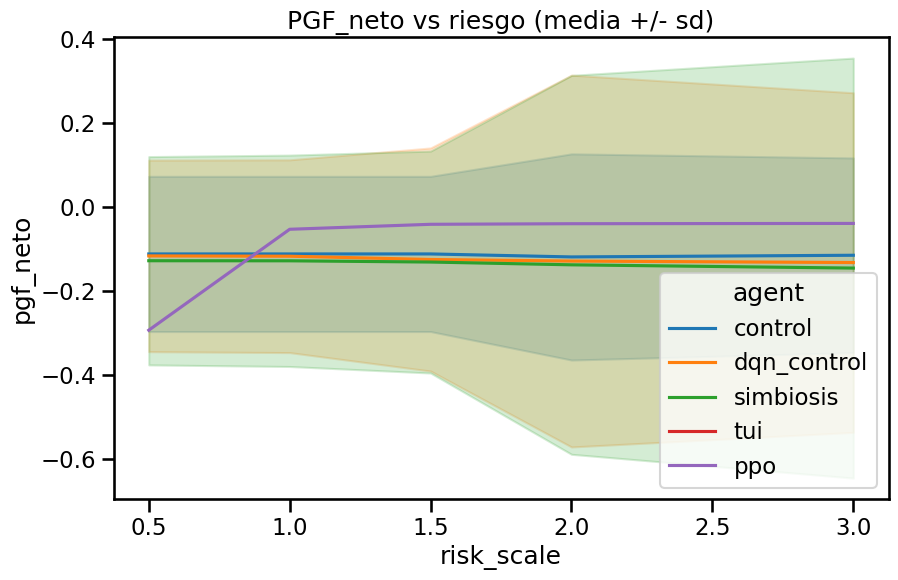

In [4]:
# Lineas PGF_neto vs riesgo
plt.figure()
sns.lineplot(data=df, x="risk_scale", y="pgf_neto", hue="agent", estimator="mean", ci="sd")
plt.title("PGF_neto vs riesgo (media +/- sd)")
pgf_line_path = REPORTS_DIR / "pgf_neto_vs_riesgo.png"
plt.savefig(pgf_line_path, dpi=200, bbox_inches="tight")
pgf_line_path

C:\Users\jrivera\AppData\Local\Temp\ipykernel_36108\3624245198.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df, x="risk_scale", y="tripwires", hue="agent", estimator="mean", ci="sd")


WindowsPath('C:/Proyectos/TUI-v4.1/results/exp_tui_pgf_vs_sota_2025/plots/tripwires_vs_riesgo.png')

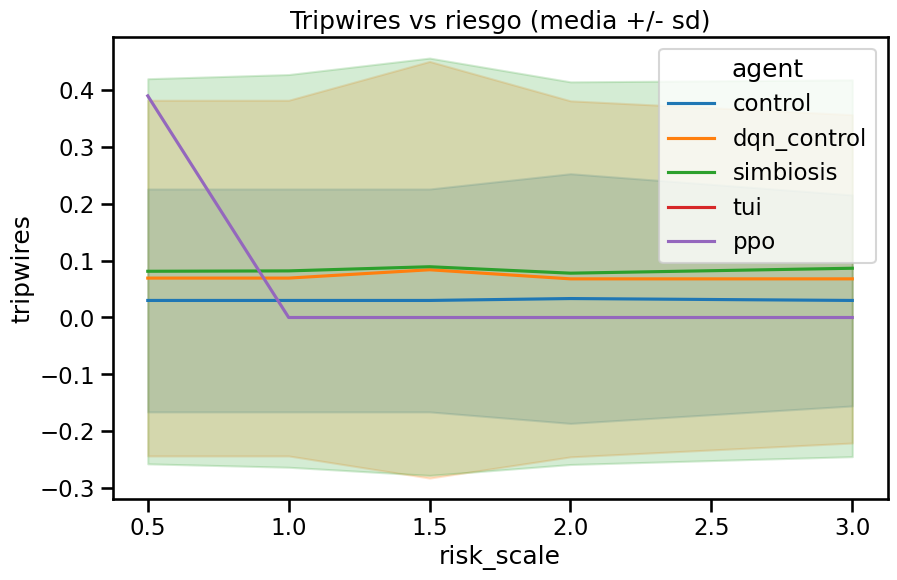

In [5]:
# Lineas tripwires vs riesgo
plt.figure()
sns.lineplot(data=df, x="risk_scale", y="tripwires", hue="agent", estimator="mean", ci="sd")
plt.title("Tripwires vs riesgo (media +/- sd)")
trip_line_path = REPORTS_DIR / "tripwires_vs_riesgo.png"
plt.savefig(trip_line_path, dpi=200, bbox_inches="tight")
trip_line_path

WindowsPath('C:/Proyectos/TUI-v4.1/results/exp_tui_pgf_vs_sota_2025/plots/pgf_neto_boxplot.png')

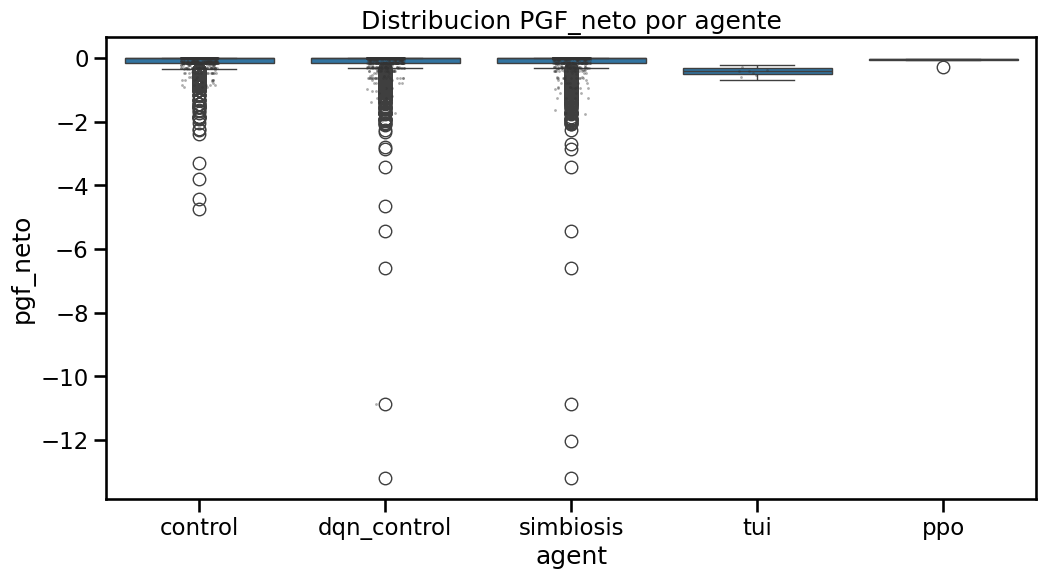

In [6]:
# Boxplots por seed para PGF_neto
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="agent", y="pgf_neto")
sns.stripplot(data=df.sample(min(len(df), 2000)), x="agent", y="pgf_neto", color="0.2", size=2, alpha=0.4)
plt.title("Distribucion PGF_neto por agente")
pgf_box_path = REPORTS_DIR / "pgf_neto_boxplot.png"
plt.savefig(pgf_box_path, dpi=200, bbox_inches="tight")
pgf_box_path

WindowsPath('C:/Proyectos/TUI-v4.1/results/exp_tui_pgf_vs_sota_2025/plots/recompensa_vs_tripwires.png')

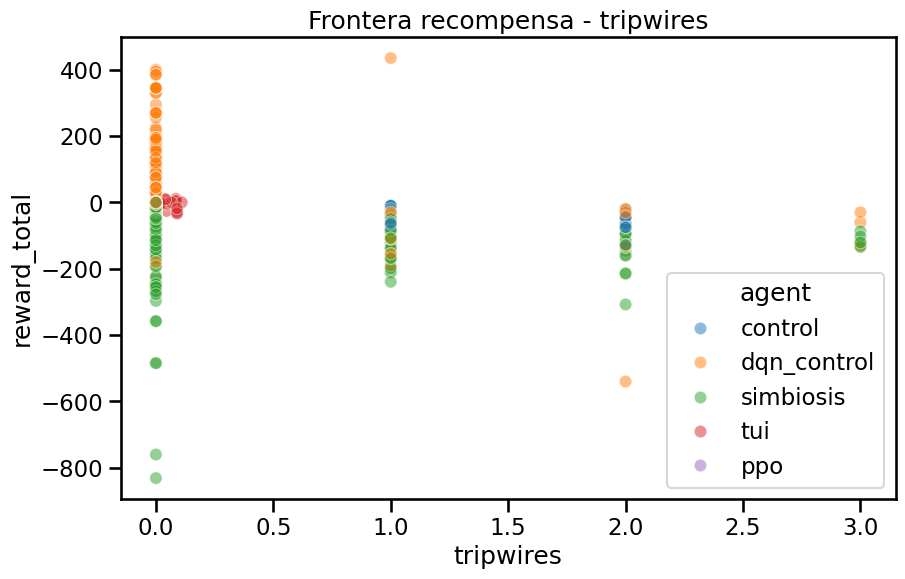

In [7]:
# Scatter recompensa vs tripwires
plt.figure()
sns.scatterplot(data=df.sample(min(len(df), 5000)), x="tripwires", y="reward_total", hue="agent", alpha=0.5)
plt.title("Frontera recompensa - tripwires")
scatter_path = REPORTS_DIR / "recompensa_vs_tripwires.png"
plt.savefig(scatter_path, dpi=200, bbox_inches="tight")
scatter_path

Graficos y tablas guardados en `reports/phase2/`. Ajusta seeds/episodios/PGF en el pipeline antes de re-ejecutar este notebook si cambian los insumos.